# Shared Understanding Implementation

Implementing the following paper's (Ghosal, T., Das, D., Ekbal, A., & Bhattacharyya, P. (2022). Novelty Detection: A Perspective from Natural Language Processing. Computational Linguistics, 48(1), 77–118.) methods

**File name:** `coli_a_00429.pdf`

## 0) Setup

In [7]:
# !pip install pandas numpy torch transformers accelerate tqdm sentence-transformers

import os, math, gc, platform
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# -------------------- DEVICE: prefer Apple GPU (MPS) --------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"   # allow CPU fallback for unsupported ops
    print("Using Apple GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")
print("Torch:", torch.__version__, "| Platform:", platform.platform())

# -------------------- PATHS --------------------
CSV_PATH  = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Attempt 1-2/Data/scaled/sentences_ALL_filled.csv"
SAVE_PATH = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Attempt_3-Shared-Agenda/Data/sentences_ALL_with_nli_novelty.csv"

# -------------------- MODEL --------------------
# (Optional speed tradeoff) MODEL_NAME = "facebook/bart-large-mnli"
MODEL_NAME = "roberta-large-mnli"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device).eval()

id2label = model.config.id2label
ENTAILMENT_ID = [i for i, lab in id2label.items() if lab.lower().startswith("entail")][0] if id2label else 2
print("Entailment label id:", ENTAILMENT_ID)

# -------------------- LOAD + NORMALIZE COLUMNS --------------------
df = pd.read_csv(CSV_PATH)

lower2orig = {c.lower(): c for c in df.columns}
session_candidates = ["session_id","session","meeting_id","mtg_id","conversation_id","thread_id"]
sentid_candidates  = ["sent_id","sentence_id","utterance_id","utt_id","turn_id","line_id","global_sent_id","index"]
text_candidates    = ["text","utterance","transcript","content","sentence","msg","message"]

def pick(cands):
    for k in cands:
        if k in lower2orig:
            return lower2orig[k]
    return None

session_col = pick(session_candidates)
sentid_col  = pick(sentid_candidates)
text_col    = pick(text_candidates)

if sentid_col is None:
    if session_col is None:
        df["_tmp_session_id"] = 0
        session_col = "_tmp_session_id"
    df["_tmp_sent_id"] = df.groupby(session_col).cumcount()
    sentid_col = "_tmp_sent_id"

rename_map = {}
if session_col and session_col != "session_id": rename_map[session_col] = "session_id"
if sentid_col  and sentid_col  != "sent_id":    rename_map[sentid_col]  = "sent_id"
if text_col    and text_col    != "text":       rename_map[text_col]    = "text"
df = df.rename(columns=rename_map)

required = {"session_id","sent_id","text"}
if not required.issubset(df.columns):
    print("Columns present:", df.columns.tolist())
    print("\nSample rows:\n", df.head(3))
    missing = required - set(df.columns)
    raise AssertionError(f"Missing required columns after auto-detect: {missing}.")

df["text"] = df["text"].astype(str).str.strip()
df = df.sort_values(["session_id","sent_id"]).reset_index(drop=True)

# -------------------- HYPERPARAMS --------------------
BATCH_SIZE  = 16
MAX_LEN     = 256    # try 192/128 for more speed
WINDOW      = 50     # try 20–30 for a first pass
TOPK_PRIORS = 5

# -------------------- INFERENCE --------------------
@torch.inference_mode()
def batched_entailment(premises, hypotheses):
    enc = tokenizer(
        premises, hypotheses,
        padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt"
    ).to(device)

    # Use autocast only on CUDA; many torch builds don't support autocast("mps") yet.
    if device.type == "cuda":
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            logits = model(**enc).logits
    else:
        logits = model(**enc).logits

    probs = torch.softmax(logits, dim=-1)[:, ENTAILMENT_ID].detach().cpu().numpy()
    return probs

results = []
for session_id, g in tqdm(df.groupby("session_id"), total=df["session_id"].nunique(), desc="Sessions"):
    texts = g["text"].tolist()
    max_entails_s, novelties_s, topix_s = [], [], []

    for i, t in enumerate(texts):
        prior_start = max(0, i - WINDOW)
        priors = texts[prior_start:i]

        if len(priors) == 0:
            max_entails_s.append(0.0)
            novelties_s.append(1.0)
            topix_s.append([])
            continue

        if len(priors) > TOPK_PRIORS:
            priors = priors[-TOPK_PRIORS:]
            prior_indices = list(range(i - len(priors), i))
        else:
            prior_indices = list(range(prior_start, i))

        entail_probs = batched_entailment(priors, [t]*len(priors))
        max_entail = float(np.max(entail_probs)) if len(entail_probs) else 0.0
        novelty    = float(1.0 - max_entail)

        max_entails_s.append(max_entail)
        novelties_s.append(novelty)

        if len(entail_probs):
            argmax_local = int(np.argmax(entail_probs))
            topix_s.append([prior_indices[argmax_local]])
        else:
            topix_s.append([])

    g = g.copy()
    g["nli_max_entail"]   = max_entails_s
    g["nli_novelty"]      = novelties_s
    g["nli_top_prior_ix"] = topix_s
    results.append(g)

    # Flush after each session (resilient to interrupts)
    pd.concat(results, ignore_index=True).to_csv(SAVE_PATH, index=False)

print(f"Saved: {SAVE_PATH}")

Using Apple GPU (MPS)
Torch: 2.2.2 | Platform: macOS-15.6.1-arm64-arm-64bit


/opt/miniconda3/envs/conv-clean/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at roberta-large-mnli were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Entailment label id: 2


Sessions: 100%|██████████| 82/82 [22:23<00:00, 16.38s/it]

Saved: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Attempt_3-Shared-Agenda/Data/sentences_ALL_with_nli_novelty.csv


## Minimal Analysis / Visuals

Matches: ['2021_05_21_ABI_S15']
Rows in 2021_05_21_ABI_S15: 495


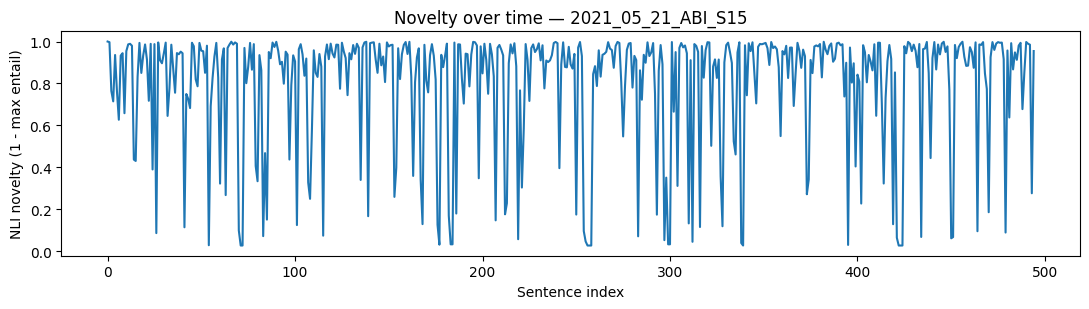


--- NEW IDEA (high novelty) ---
sent_id: 0
novelty: 1.0
text: Failures?

--- REINFORCEMENT (low novelty) ---
sent_id: 71
novelty: 0.027
text: Yeah.
entailed by prior: Yeah.


In [10]:
import pandas as pd, numpy as np, re
import matplotlib.pyplot as plt

PATH = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Attempt_3-Shared-Agenda/Data/sentences_ALL_with_nli_novelty.csv"
SESSION_KEY = "ABI_S15"   # <- partial key, so it matches e.g. "2021_05_21_ABI_S15"

df = pd.read_csv(PATH)

# Normalize
df["session_id"] = df["session_id"].astype(str).str.strip()
for col in ["sent_id","nli_novelty","nli_max_entail"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Find matching sessions
matches = [s for s in df["session_id"].unique() if SESSION_KEY.lower() in s.lower()]
print("Matches:", matches)
if not matches:
    raise SystemExit(f"No sessions found containing '{SESSION_KEY}'")
SESSION = matches[0]   # pick the first match

# Slice
g = (df[df["session_id"] == SESSION]
       .dropna(subset=["sent_id","nli_novelty"])
       .sort_values("sent_id")
       .reset_index(drop=True))
print(f"Rows in {SESSION}:", len(g))

# Plot novelty curve
plt.figure(figsize=(11,3.2))
plt.plot(g["sent_id"], g["nli_novelty"])
plt.title(f"Novelty over time — {SESSION}")
plt.xlabel("Sentence index")
plt.ylabel("NLI novelty (1 - max entail)")
plt.tight_layout(); plt.show()

# Helper: pull prior text
def prior_text(row, gframe):
    s = str(row.get("nli_top_prior_ix",""))
    m = re.search(r"-?\d+", s)
    if not m: return None
    pidx = int(m.group())
    hit = gframe[gframe["sent_id"] == pidx]
    return None if hit.empty else hit["text"].iloc[0]

# Examples
hi = g.loc[g["nli_novelty"].idxmax()]
lo = g.loc[g["nli_novelty"].idxmin()]

print("\n--- NEW IDEA (high novelty) ---")
print("sent_id:", int(hi["sent_id"]))
print("novelty:", round(float(hi["nli_novelty"]), 3))
print("text:", hi["text"])

print("\n--- REINFORCEMENT (low novelty) ---")
print("sent_id:", int(lo["sent_id"]))
print("novelty:", round(float(lo["nli_novelty"]), 3))
print("text:", lo["text"])
print("entailed by prior:", prior_text(lo, g))

## Step 2: Analyze & Report Novelty Patterns Across Sessions

In [12]:
import os, re, json
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

PATH = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Attempt_3-Shared-Agenda/Data/sentences_ALL_with_nli_novelty.csv"
OUTDIR = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Attempt_3-Shared-Agenda/Reports"
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(PATH)
df["session_id"] = df["session_id"].astype(str).str.strip()
for col in ["sent_id","nli_novelty","nli_max_entail"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

def prior_text(row, gframe):
    s = str(row.get("nli_top_prior_ix",""))
    m = re.search(r"-?\d+", s)
    if not m: return None
    pidx = int(m.group())
    hit = gframe[gframe["sent_id"] == pidx]
    return None if hit.empty else hit["text"].iloc[0]

summ_rows = []
for sid, g in df.groupby("session_id"):
    g = g.dropna(subset=["sent_id","nli_novelty"]).sort_values("sent_id")
    if g.empty: continue

    # Plot novelty curve
    plt.figure(figsize=(10,3.2))
    plt.plot(g["sent_id"], g["nli_novelty"])
    plt.title(f"Novelty over time — {sid}")
    plt.xlabel("Sentence index"); plt.ylabel("NLI novelty (1 - max entail)")
    plt.tight_layout()
    png_path = os.path.join(OUTDIR, f"{sid}_novelty.png")
    plt.savefig(png_path, dpi=150); plt.close()

    # Examples: top-3 novel, top-3 reinforced
    top_new = g.nlargest(3, "nli_novelty").copy()
    top_old = g.nsmallest(3, "nli_novelty").copy()
    for df_ in (top_new, top_old):
        df_["entailed_by_prior_text"] = df_.apply(lambda r: prior_text(r, g), axis=1)

    # Save examples
    ex_path = os.path.join(OUTDIR, f"{sid}_examples.csv")
    pd.concat([
        top_new.assign(example_type="new_idea"),
        top_old.assign(example_type="reinforcement")
    ], ignore_index=True)[["session_id","sent_id","nli_novelty","text","entailed_by_prior_text","example_type"]].to_csv(ex_path, index=False)

    # Session summary metrics
    nov = g["nli_novelty"].to_numpy()
    thresh = 0.3
    tail = 0
    for x in nov[::-1]:
        if x < thresh: tail += 1
        else: break

    summ_rows.append({
        "session_id": sid,
        "n_sent": int(len(g)),
        "mean_novelty": float(np.mean(nov)),
        "median_novelty": float(np.median(nov)),
        "pct_high_novelty_(>0.8)": float(np.mean(nov > 0.8)),
        "longest_final_low_novelty_run": int(tail),
        "plot_path": png_path,
        "examples_path": ex_path
    })

# Master summary
summary = pd.DataFrame(summ_rows).sort_values(
    ["longest_final_low_novelty_run","pct_high_novelty_(>0.8)"], ascending=[False, True]
)
summary_path = os.path.join(OUTDIR, "SESSION_SUMMARY.csv")
summary.to_csv(summary_path, index=False)
print("Wrote:", summary_path)

Wrote: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Attempt_3-Shared-Agenda/Reports/SESSION_SUMMARY.csv


In [13]:
import pandas as pd

summary_path = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Attempt_3-Shared-Agenda/Reports/SESSION_SUMMARY.csv"
S = pd.read_csv(summary_path)

print(S.head(3))
print("\nColumns:", S.columns.tolist())
print("\nTop by longest_final_low_novelty_run (most ‘settled’ at the end):")
print(S.sort_values("longest_final_low_novelty_run", ascending=False).head(10)[
    ["session_id","n_sent","longest_final_low_novelty_run","mean_novelty","pct_high_novelty_(>0.8)"]
])

print("\nTop by pct_high_novelty_(>0.8) (most idea-heavy):")
print(S.sort_values("pct_high_novelty_(>0.8)", ascending=False).head(10)[
    ["session_id","n_sent","pct_high_novelty_(>0.8)","mean_novelty","longest_final_low_novelty_run"]
])

          session_id  n_sent  mean_novelty  median_novelty  \
0  2021_04_23_MND_S1     387      0.778086        0.946086   
1  2021_05_21_ABI_S4     622      0.788242        0.931308   
2  2021_04_22_MND_S1     478      0.787271        0.927916   

   pct_high_novelty_(>0.8)  longest_final_low_novelty_run  \
0                 0.713178                              3   
1                 0.720257                              2   
2                 0.721757                              2   

                                           plot_path  \
0  /Users/maxchalekson/Projects/NICO-Research/NIC...   
1  /Users/maxchalekson/Projects/NICO-Research/NIC...   
2  /Users/maxchalekson/Projects/NICO-Research/NIC...   

                                       examples_path  
0  /Users/maxchalekson/Projects/NICO-Research/NIC...  
1  /Users/maxchalekson/Projects/NICO-Research/NIC...  
2  /Users/maxchalekson/Projects/NICO-Research/NIC...  

Columns: ['session_id', 'n_sent', 'mean_novelty', 'median_no

### Three quick visuals

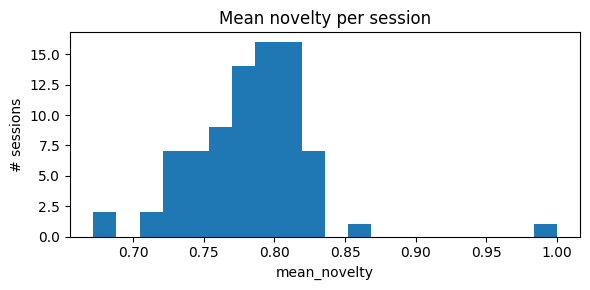

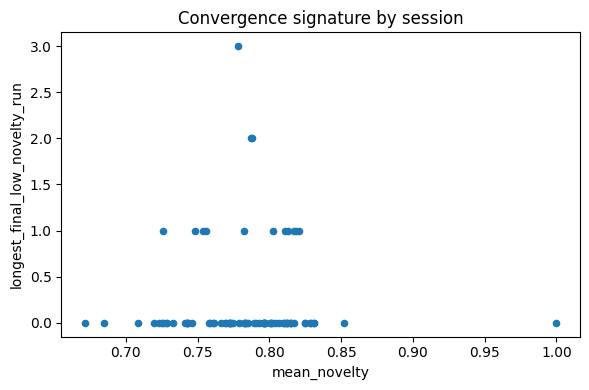

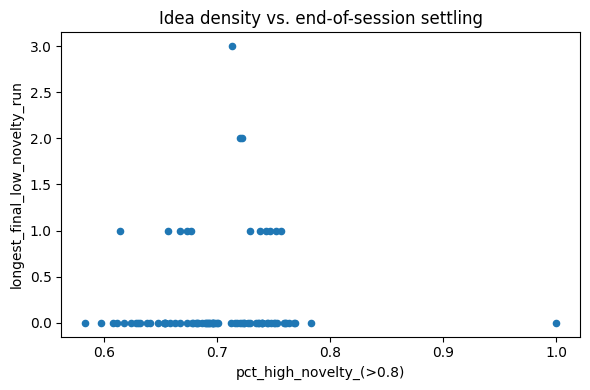

In [14]:
import matplotlib.pyplot as plt

# 1) Distribution of mean novelty across sessions
plt.figure(figsize=(6,3))
plt.hist(S["mean_novelty"], bins=20)
plt.title("Mean novelty per session"); plt.xlabel("mean_novelty"); plt.ylabel("# sessions")
plt.tight_layout(); plt.show()

# 2) Convergence signature: final low-novelty run length vs mean novelty
plt.figure(figsize=(6,4))
plt.scatter(S["mean_novelty"], S["longest_final_low_novelty_run"], s=20)
plt.xlabel("mean_novelty"); plt.ylabel("longest_final_low_novelty_run")
plt.title("Convergence signature by session")
plt.tight_layout(); plt.show()

# 3) How idea-heavy is a session vs. how it ends
plt.figure(figsize=(6,4))
plt.scatter(S["pct_high_novelty_(>0.8)"], S["longest_final_low_novelty_run"], s=20)
plt.xlabel("pct_high_novelty_(>0.8)"); plt.ylabel("longest_final_low_novelty_run")
plt.title("Idea density vs. end-of-session settling")
plt.tight_layout(); plt.show()

## Checking with a few sessions

This is just the analysis part

In [15]:
# One-shot reporting script: per-session plots, exemplars, and a master summary
# Assumes you've already produced sentences_ALL_with_nli_novelty.csv with columns:
# ['session_id','sent_id','text','nli_novelty','nli_max_entail','nli_top_prior_ix', ...]
import os, re, json
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

# -------- Paths (edit as needed) --------
IN_CSV  = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Attempt_3-Shared-Agenda/Data/sentences_ALL_with_nli_novelty.csv"
OUTDIR  = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Attempt_3-Shared-Agenda/Reports"
os.makedirs(OUTDIR, exist_ok=True)

# -------- Load & hygiene --------
df = pd.read_csv(IN_CSV)
df["session_id"] = df["session_id"].astype(str).str.strip()

for col in ["sent_id","nli_novelty","nli_max_entail"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Optional: drop rows with empty text
if "text" in df.columns:
    df["text"] = df["text"].astype(str).str.strip()
    df = df[df["text"].str.len() > 0]

# Helper: retrieve the prior sentence text that most entailed the current one (if any)
def prior_text(row, gframe):
    s = str(row.get("nli_top_prior_ix",""))
    m = re.search(r"-?\d+", s)  # first integer inside [], if present
    if not m: return None
    pidx = int(m.group())
    hit = gframe[gframe["sent_id"] == pidx]
    return None if hit.empty else hit["text"].iloc[0]

summ_rows = []
SESSION_PLOT_LIMIT = None   # set an int to limit how many sessions to plot while testing
HIGH_NOV_THRESH    = 0.80   # % of sentences above this = “idea-heavy”
SETTLED_TAIL_THRESH= 0.30   # trailing run below this = “settled”

for sid_i, (sid, g) in enumerate(df.groupby("session_id"), start=1):
    # keep numeric + ordered
    g = (g.dropna(subset=["sent_id","nli_novelty"])
           .sort_values("sent_id")
           .reset_index(drop=True))
    if g.empty: 
        continue

    # -------- Plot novelty curve --------
    plt.figure(figsize=(10,3.2))
    plt.plot(g["sent_id"], g["nli_novelty"])
    plt.title(f"Novelty over time — {sid}")
    plt.xlabel("Sentence index")
    plt.ylabel("NLI novelty (1 - max entail)")
    plt.tight_layout()
    plot_path = os.path.join(OUTDIR, f"{sid}_novelty.png")
    plt.savefig(plot_path, dpi=150); plt.close()

    # -------- Examples: top-3 novel & top-3 reinforced --------
    top_new = g.nlargest(3, "nli_novelty").copy()
    top_old = g.nsmallest(3, "nli_novelty").copy()
    for df_ in (top_new, top_old):
        df_["entailed_by_prior_text"] = df_.apply(lambda r: prior_text(r, g), axis=1)

    examples = pd.concat(
        [top_new.assign(example_type="new_idea"),
         top_old.assign(example_type="reinforcement")],
        ignore_index=True
    )[["session_id","sent_id","nli_novelty","text","entailed_by_prior_text","example_type"]]

    ex_path = os.path.join(OUTDIR, f"{sid}_examples.csv")
    examples.to_csv(ex_path, index=False)

    # -------- Session summary metrics --------
    nov = g["nli_novelty"].to_numpy()
    # trailing “settled” run: count from the end while novelty < threshold
    tail = 0
    for x in nov[::-1]:
        if x < SETTLED_TAIL_THRESH: tail += 1
        else: break

    summ_rows.append({
        "session_id": sid,
        "n_sent": int(len(g)),
        "mean_novelty": float(np.mean(nov)),
        "median_novelty": float(np.median(nov)),
        f"pct_high_novelty_(>{HIGH_NOV_THRESH})": float(np.mean(nov > HIGH_NOV_THRESH)),
        "longest_final_low_novelty_run": int(tail),
        "plot_path": plot_path,
        "examples_path": ex_path
    })

    if SESSION_PLOT_LIMIT and sid_i >= SESSION_PLOT_LIMIT:
        break

# -------- Master summary --------
summary = pd.DataFrame(summ_rows).sort_values(
    ["longest_final_low_novelty_run", f"pct_high_novelty_(>{HIGH_NOV_THRESH})"],
    ascending=[False, True]
)
summary_path = os.path.join(OUTDIR, "SESSION_SUMMARY.csv")
summary.to_csv(summary_path, index=False)
print("Wrote:", summary_path)
print("Top few sessions by ‘settled’ tail:")
print(summary[["session_id","n_sent","longest_final_low_novelty_run","mean_novelty"]].head(10))

Wrote: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Attempt_3-Shared-Agenda/Reports/SESSION_SUMMARY.csv
Top few sessions by ‘settled’ tail:
            session_id  n_sent  longest_final_low_novelty_run  mean_novelty
8    2021_04_23_MND_S1     387                              3      0.778086
42   2021_05_21_ABI_S4     622                              2      0.788242
0    2021_04_22_MND_S1     478                              2      0.787271
32   2021_05_21_ABI_S1     464                              1      0.726195
10  2021_04_23_MND_S11     487                              1      0.753776
29   2021_05_20_ABI_S6     496                              1      0.747920
51   2021_06_10_SLU_S4     621                              1      0.756041
67   2021_06_11_SLU_S9     566                              1      0.782417
30   2021_05_20_ABI_S7     469                              1      0.802627
2    2021_04_22_MND_S3     423                              1      0.816928


## testing code chunk

Using plus/minus 2 sentences around highest/lowest novelty examples. giving us the ability to show how a new idea emerges or how something is being reinforced. Can be adjusted though.

In [16]:
# --- EXTRACT TOP/BOTTOM NOVELTY EXAMPLES WITH ±N CONTEXT ---
import os, re, json, textwrap
import pandas as pd
import numpy as np

# ======= PARAMETERS (edit these) =======
CSV_PATH = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Attempt_3-Shared-Agenda/Data/sentences_ALL_with_nli_novelty.csv"
OUTDIR   = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Attempt_3-Shared-Agenda/Reports"

TOPK_PER_SESSION = 3    # how many "new" and "reinforcement" examples per session
CONTEXT_N        = 2    # show ±N sentences of context around each target
SESSION_FILTER   = None # e.g., ["2021_05_21_ABI_S15"] to limit; or None for all
MIN_SENT_LEN     = 3    # ignore ultra-short sentences (tokens) for examples
# ======================================

os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
# Normalize types/columns
df["session_id"] = df["session_id"].astype(str).str.strip()
for col in ["sent_id","nli_novelty","nli_max_entail"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["text"] = df["text"].astype(str).fillna("")

if SESSION_FILTER is not None:
    df = df[df["session_id"].isin(SESSION_FILTER)].copy()

def prior_text_for_row(row, session_frame):
    """Parse nli_top_prior_ix (like '[123]' or '[]' or '[1, 45]') and return the first matching prior text."""
    s = str(row.get("nli_top_prior_ix", ""))
    m = re.search(r"-?\d+", s)
    if not m:
        return None, None
    pidx = int(m.group())
    hit = session_frame[session_frame["sent_id"] == pidx]
    if hit.empty: 
        return pidx, None
    return pidx, hit["text"].iloc[0]

def grab_context(session_frame, center_idx, n=2):
    """
    Return lists of (sent_id, text) for context before/after a center index within the dataframe slice (0-based index).
    """
    start = max(0, center_idx - n)
    end   = min(len(session_frame), center_idx + n + 1)
    before = []
    after  = []
    for i in range(start, center_idx):
        before.append((int(session_frame.iloc[i]["sent_id"]), session_frame.iloc[i]["text"]))
    for i in range(center_idx + 1, end):
        after.append((int(session_frame.iloc[i]["sent_id"]), session_frame.iloc[i]["text"]))
    return before, after

def token_len(s):
    return len(str(s).split())

all_rows = []
md_blocks = []

sessions = df["session_id"].unique().tolist()
for sid in sessions:
    g = (df[df["session_id"] == sid]
           .dropna(subset=["sent_id","nli_novelty"])
           .sort_values("sent_id")
           .reset_index(drop=True))
    if g.empty:
        continue

    # Optionally filter out super-short lines from candidate pool
    g_candidates = g[g["text"].map(token_len) >= MIN_SENT_LEN].copy()
    if g_candidates.empty:
        g_candidates = g.copy()

    top_new = g_candidates.nlargest(TOPK_PER_SESSION, "nli_novelty", keep="first")
    top_old = g_candidates.nsmallest(TOPK_PER_SESSION, "nli_novelty", keep="first")

    # Build per-session examples table
    per_session = []

    def add_examples(subset, example_type):
        for _, row in subset.iterrows():
            # locate index in the sorted full session frame
            locs = g.index[g["sent_id"] == row["sent_id"]].tolist()
            if not locs:
                continue
            i = locs[0]

            prior_ix, prior_txt = prior_text_for_row(row, g)
            before, after = grab_context(g, i, n=CONTEXT_N)

            per_session.append({
                "session_id": sid,
                "example_type": example_type,   # "new_idea" or "reinforcement"
                "sent_id": int(row["sent_id"]),
                "nli_novelty": float(row["nli_novelty"]),
                "text": row["text"],
                "entailed_prior_sent_id": prior_ix,
                "entailed_prior_text": prior_txt,
                "context_before": json.dumps(before, ensure_ascii=False),
                "context_after": json.dumps(after, ensure_ascii=False),
            })

    add_examples(top_new, "new_idea")
    add_examples(top_old, "reinforcement")

    per_session_df = pd.DataFrame(per_session)
    # Save per-session CSV
    ex_path = os.path.join(OUTDIR, f"{sid}_EXAMPLES_with_context.csv")
    per_session_df.to_csv(ex_path, index=False)

    # Minimal markdown preview block (first new + first reinforcement if present)
    def fmt_ctx(items):
        lines = []
        for sid_i, txt in items:
            lines.append(f"- [{sid_i}] {txt}")
        return "\n".join(lines)

    md = [f"## {sid}",
          ""]
    for ex_type in ["new_idea","reinforcement"]:
        blk = per_session_df[per_session_df["example_type"] == ex_type]
        if blk.empty: 
            continue
        row0 = blk.sort_values(
            "nli_novelty", ascending=(ex_type=="reinforcement")
        ).iloc[0]
        before = json.loads(row0["context_before"])
        after  = json.loads(row0["context_after"])

        md += [
            f"**{ex_type.replace('_',' ').title()}** (sent_id={row0['sent_id']}, novelty={row0['nli_novelty']:.3f})",
            "",
            "*Context (−)*",
            fmt_ctx(before) if before else "_None_",
            "",
            "*Target*",
            f"> {row0['text']}",
            "",
            "*Context (+)*",
            fmt_ctx(after) if after else "_None_",
            "",
            "*Most-entailed prior*",
            f"- [{row0['entailed_prior_sent_id']}] {row0['entailed_prior_text']}" if pd.notna(row0["entailed_prior_text"]) else "_None_",
            ""
        ]
    md_blocks.append("\n".join(md))

# Save combined CSV of all examples
combined = pd.concat(
    [pd.read_csv(os.path.join(OUTDIR, f)) 
     for f in os.listdir(OUTDIR) if f.endswith("_EXAMPLES_with_context.csv")],
    ignore_index=True
) if any(f.endswith("_EXAMPLES_with_context.csv") for f in os.listdir(OUTDIR)) else pd.DataFrame()
comb_path = os.path.join(OUTDIR, "ALL_SESSIONS_EXAMPLES_with_context.csv")
combined.to_csv(comb_path, index=False)

# Save a simple Markdown report
md_path = os.path.join(OUTDIR, "EXCERPTS_REPORT.md")
with open(md_path, "w", encoding="utf-8") as f:
    f.write("# NLI Novelty Excerpts (±{} context)\n\n".format(CONTEXT_N))
    f.write("_Note: window size is illustrative; happy to adjust._\n\n")
    f.write("\n\n".join(md_blocks))

print("Wrote per-session examples, combined CSV, and Markdown report:")
print(" - Combined:", comb_path)
print(" - Markdown:", md_path)
print(" - Per-session files saved in:", OUTDIR)

Wrote per-session examples, combined CSV, and Markdown report:
 - Combined: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Attempt_3-Shared-Agenda/Reports/ALL_SESSIONS_EXAMPLES_with_context.csv
 - Markdown: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Attempt_3-Shared-Agenda/Reports/EXCERPTS_REPORT.md
 - Per-session files saved in: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Attempt_3-Shared-Agenda/Reports


## Interpreting and Illustrating the Paper's Methodology

In [ ]:
import pandas as pd, matplotlib.pyplot as plt

PATH = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Attempt_3-Shared-Agenda/Reports/ALL_SESSIONS_EXAMPLES_with_context.csv"
df = pd.read_csv(PATH)

# Pick one session that looks interesting
SESSION = "2021_05_21_ABI_S15"   # change as needed
g = df[df.session_id == SESSION].reset_index(drop=True)

# 1) Pull one "new_idea" example
seed = g[g["example_type"]=="new_idea"].iloc[0]
print("\n--- SEED IDEA ---")
print(seed["text"])

# 2) Check if it reappears later (naive keyword search, can refine)
later = g[g["sent_id"] > seed["sent_id"]]
hits = later[later["text"].str.contains(seed["text"].split()[0], case=False)] # crude: look for keyword overlap
print("\n--- LATER REPETITIONS ---")
print(hits[["sent_id","text"]].head())

# 3) Plot novelty curve
plt.figure(figsize=(10,3.5))
plt.plot(g["sent_id"], g["nli_novelty"], label="Novelty")
plt.axvline(seed["sent_id"], color="red", linestyle="--", label="New Idea")
plt.title(f"Novelty curve for {SESSION}")
plt.xlabel("Sentence ID"); plt.ylabel("Novelty (1 - max entail)")
plt.legend(); plt.show()